# Previsão do Nível de Depressão e Ansiedade em Idosos — Modelos Avançados

## Objetivo

Este notebook complementa a análise com modelos tradicionais, aplicando três modelos de **gradient boosting avançado** à mesma questão de investigação:

> **Conseguimos prever o nível de depressão e ansiedade em idosos a partir de variáveis de estilo de vida e sociodemográficas, nomeadamente dados de atividade física?**

Os modelos avaliados são:
- **XGBoost** (Extreme Gradient Boosting)
- **LightGBM** (Light Gradient Boosting Machine)
- **CatBoost** (Categorical Boosting)

Estes modelos diferem dos tradicionais por:
- Utilizarem técnicas de regularização mais sofisticadas
- Serem mais eficientes computacionalmente
- Escalarem melhor com o aumento de dados
- Terem hiperparâmetros que permitem um controlo mais fino do overfitting

## Dataset

- **Ficheiro:** `Dataset_Idosos.csv`
- **Dimensão:** 3915 participantes × 17 variáveis
- **Natureza:** Dataset sintético gerado para fins académicos
- **Features de treino:** idade, género, educação, rendimento, estado civil, situação de vida, comorbilidades, atividade física (dias, minutos por sessão, tipo, intensidade), horas de sono

## Nota sobre Codificação dos Targets

O XGBoost e o LightGBM requerem targets numéricos. As classes são codificadas com `LabelEncoder` antes do treino e descodificadas para avaliação, garantindo comparabilidade com os modelos tradicionais.

## Estratégia de Validação

Idêntica ao notebook de modelos tradicionais: **split 80/20** com **validação cruzada estratificada de 5 folds**.


---
## 1. Importações e Configuração

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Instalar bibliotecas caso necessário
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Modelos avançados
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Dependências carregadas com sucesso.')

✅ Dependências carregadas com sucesso.


---
## 2. Carregamento e Preparação dos Dados

In [11]:
df = pd.read_csv('/content/drive/MyDrive/IACD/Projeto/notebooks/Dataset_Idosos.csv', sep=';')
print(f'Dimensão: {df.shape[0]} participantes × {df.shape[1]} variáveis')
df.head()

Dimensão: 3915 participantes × 16 variáveis


,participant_id,age,gender,education_years,monthly_income,marital_status,living_situation,comorbidities_count,physical_activity_days_per_week,physical_activity_minutes_per_session,physical_activity_total_minutes_week,physical_activity_type,physical_activity_intensity,sleep_hours,phq9_total,gad7_total
0,1,65,1,3,950.15,1,1,1.0,7.0,52.0,364.0,1.0,2.0,7.9,0.0,0.0
1,2,71,1,6,1600.25,1,1,2.0,5.0,37.0,185.0,1.0,2.0,7.2,1.0,1.0
2,3,68,2,7,1800.10,2,2,2.0,6.0,43.0,258.0,1.0,2.0,7.4,2.0,2.0
3,4,70,2,5,1350.35,1,1,2.0,5.0,35.0,175.0,1.0,2.0,7.0,1.0,1.0
4,5,68,1,14,4500.20,2,2,2.0,7.0,45.0,315.0,5.0,3.0,7.6,2.0,2.0


In [5]:
# Criar variáveis target com classificações clínicas oficiais

# PHQ-9: 5 classes
bins_phq9   = [-1, 4, 9, 14, 19, 27]
labels_phq9 = ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']
df['phq9_classe'] = pd.cut(df['phq9_total'], bins=bins_phq9, labels=labels_phq9)

# GAD-7: 4 classes
bins_gad7   = [-1, 4, 9, 14, 21]
labels_gad7 = ['Mínima', 'Leve', 'Moderada', 'Grave']
df['gad7_classe'] = pd.cut(df['gad7_total'], bins=bins_gad7, labels=labels_gad7)

print('Distribuição PHQ-9:')
print(df['phq9_classe'].value_counts().sort_index())
print()
print('Distribuição GAD-7:')
print(df['gad7_classe'].value_counts().sort_index())

Distribuição PHQ-9:
phq9_classe
Mínima        1648
Leve          1040
Moderada       555
Mod. grave     405
Grave          267
Name: count, dtype: int64

Distribuição GAD-7:
gad7_classe
Mínima      2185
Leve         901
Moderada     544
Grave        285
Name: count, dtype: int64


In [6]:
# Definir features de treino — as mesmas do notebook de tradicionais
EXCLUDE  = ['participant_id', 'phq9_total', 'gad7_total', 'phq9_classe', 'gad7_classe']
FEATURES = [c for c in df.columns if c not in EXCLUDE]

print(f'Total de features: {len(FEATURES)}')
print(FEATURES)

Total de features: 13
['age', 'gender', 'education_years', 'monthly_income', 'marital_status', 'living_situation', 'comorbidities_count', 'physical_activity_days_per_week', 'physical_activity_minutes_per_session', 'physical_activity_total_minutes_week', 'physical_activity_type', 'physical_activity_intensity', 'sleep_hours']


---
## 3. Pré-processamento e Split

### Nota sobre Codificação dos Targets

O XGBoost e o LightGBM requerem targets numéricos (inteiros de 0 a N-1). O CatBoost aceita strings, mas por consistência usamos `LabelEncoder` em todos os modelos. A descodificação é feita antes da avaliação para garantir que as métricas são calculadas sobre os nomes das classes originais.

In [7]:
df_model = df.dropna(subset=['phq9_classe', 'gad7_classe']).copy()
print(f'Amostras totais: {len(df)}')
print(f'Amostras após remover nulos nos targets: {len(df_model)}')

X = df_model[FEATURES]

# LabelEncoder — necessário para XGBoost e LightGBM
le_phq9 = LabelEncoder()
le_gad7 = LabelEncoder()

# Fit com ordem clínica para consistência
le_phq9.fit(labels_phq9)
le_gad7.fit(labels_gad7)

y_phq9_str = df_model['phq9_classe'].astype(str)
y_gad7_str = df_model['gad7_classe'].astype(str)
y_phq9_enc = le_phq9.transform(y_phq9_str)
y_gad7_enc = le_gad7.transform(y_gad7_str)

print(f'\nClasses PHQ-9 (codificação): {dict(zip(le_phq9.classes_, le_phq9.transform(le_phq9.classes_)))}')
print(f'Classes GAD-7 (codificação): {dict(zip(le_gad7.classes_, le_gad7.transform(le_gad7.classes_)))}')

Amostras totais: 3915
Amostras após remover nulos nos targets: 3915

Classes PHQ-9 (codificação): {np.str_('Grave'): np.int64(0), np.str_('Leve'): np.int64(1), np.str_('Mod. grave'): np.int64(2), np.str_('Moderada'): np.int64(3), np.str_('Mínima'): np.int64(4)}
Classes GAD-7 (codificação): {np.str_('Grave'): np.int64(0), np.str_('Leve'): np.int64(1), np.str_('Moderada'): np.int64(2), np.str_('Mínima'): np.int64(3)}


In [8]:
# Split 80/20 estratificado
X_train_phq9, X_test_phq9, y_train_phq9, y_test_phq9 = train_test_split(
    X, y_phq9_enc, test_size=0.20, random_state=SEED, stratify=y_phq9_enc
)
X_train_gad7, X_test_gad7, y_train_gad7, y_test_gad7 = train_test_split(
    X, y_gad7_enc, test_size=0.20, random_state=SEED, stratify=y_gad7_enc
)

# Versões em string para métricas legíveis
y_test_phq9_str = le_phq9.inverse_transform(y_test_phq9)
y_test_gad7_str = le_gad7.inverse_transform(y_test_gad7)

print(f'Treino PHQ-9: {len(X_train_phq9)} | Teste PHQ-9: {len(X_test_phq9)}')
print(f'Treino GAD-7: {len(X_train_gad7)} | Teste GAD-7: {len(X_test_gad7)}')

# Validação cruzada estratificada
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print('\n✅ Split e CV configurados.')

Treino PHQ-9: 3132 | Teste PHQ-9: 783
Treino GAD-7: 3132 | Teste GAD-7: 783

✅ Split e CV configurados.


---
## 4. Definição dos Modelos

### XGBoost
Implementação optimizada de gradient boosting com regularização L1 e L2. Usa construção de árvores por nível (*level-wise*) e é particularmente eficaz em dados tabulares.

### LightGBM
Gradient boosting com construção de árvores por folha (*leaf-wise*), o que permite maior profundidade com menor custo computacional. Mais rápido que o XGBoost em datasets grandes.

### CatBoost
Gradient boosting otimizado para variáveis categóricas, com codificação ordenada que evita overfitting. Funciona bem sem necessidade de pré-processamento extensivo.

In [39]:
# Imputação da mediana — aplicada antes do treino (não há pipeline pois os modelos
# avançados aceitam NaN nativamente, mas mantemos consistência com o notebook anterior)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_phq9_imp = imputer.fit_transform(X_train_phq9)
X_test_phq9_imp  = imputer.transform(X_test_phq9)

imputer_gad7 = SimpleImputer(strategy='median')
X_train_gad7_imp = imputer_gad7.fit_transform(X_train_gad7)
X_test_gad7_imp  = imputer_gad7.transform(X_test_gad7)

n_classes_phq9 = len(le_phq9.classes_)
n_classes_gad7 = len(le_gad7.classes_)

models = {
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='mlogloss',
        random_state=SEED,
        verbosity=0,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=SEED,
        verbosity=-1,
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        l2_leaf_reg=3.0,
        random_seed=SEED,
        verbose=0,
    ),
}

print(f'Total de modelos: {len(models)}')
print('✅ Modelos definidos.')

Total de modelos: 3
✅ Modelos definidos.


---
## 5. Treino e Avaliação dos Modelos

Para cada modelo e cada target:
1. **5-fold cross-validation** no conjunto de treino (F1 Macro)
2. Treino no conjunto de treino completo
3. Avaliação no **conjunto de teste holdout**

**Métricas:** Accuracy, F1 Macro, F1 Weighted

In [40]:
def evaluate_advanced(name, model, X_train, y_train, X_test, y_test, y_test_str, le, cv):
    """
    Avalia um modelo avançado com cross-validation e no conjunto de teste.
    Os targets são numéricos (LabelEncoder) mas as métricas são calculadas
    sobre os nomes das classes originais para comparabilidade.
    """
    # Cross-validation — F1 Macro sobre targets numéricos
    cv_f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    # Treino final
    model.fit(X_train, y_train)
    y_pred_enc = model.predict(X_test)
    y_pred_str = le.inverse_transform(y_pred_enc.astype(int))

    test_acc    = accuracy_score(y_test_str, y_pred_str)
    test_f1_mac = f1_score(y_test_str, y_pred_str, average='macro', zero_division=0)
    test_f1_wgt = f1_score(y_test_str, y_pred_str, average='weighted', zero_division=0)

    return {
        'Modelo': name,
        'CV Accuracy (média)': cv_acc.mean(),
        'CV Accuracy (std)': cv_acc.std(),
        'CV F1 Macro (média)': cv_f1.mean(),
        'CV F1 Macro (std)': cv_f1.std(),
        'Teste Accuracy': test_acc,
        'Teste F1 Macro': test_f1_mac,
        'Teste F1 Weighted': test_f1_wgt,
        'y_pred': y_pred_str,
    }

print('✅ Função de avaliação definida.')

✅ Função de avaliação definida.


### 5.1 Treino — PHQ-9 (Depressão)

In [41]:
results_phq9 = []
predictions_phq9 = {}

for name, model in models.items():
    r = evaluate_advanced(name, model,
                          X_train_phq9_imp, y_train_phq9,
                          X_test_phq9_imp, y_test_phq9,
                          y_test_phq9_str, le_phq9, CV)
    predictions_phq9[name] = r.pop('y_pred')
    results_phq9.append(r)
    print(f"{name:<12} | CV F1: {r['CV F1 Macro (média)']:.4f} ± {r['CV F1 Macro (std)']:.4f} "
          f"| Teste F1: {r['Teste F1 Macro']:.4f} | Teste Acc: {r['Teste Accuracy']:.4f}")

XGBoost      | CV F1: 0.7701 ± 0.0135 | Teste F1: 0.7770 | Teste Acc: 0.7918
LightGBM     | CV F1: 0.7615 ± 0.0080 | Teste F1: 0.7822 | Teste Acc: 0.7957
CatBoost     | CV F1: 0.7608 ± 0.0071 | Teste F1: 0.7665 | Teste Acc: 0.7778


In [42]:
# Guardar modelos base treinados
trained_models_phq9 = {}
trained_models_gad7 = {}

for name, model in models.items():
    # Re-treinar para guardar o modelo final
    pipe_phq9 = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe_phq9.fit(X_train_phq9_imp, y_train_phq9)
    trained_models_phq9[name] = pipe_phq9

    pipe_gad7 = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe_gad7.fit(X_train_gad7_imp, y_train_gad7)
    trained_models_gad7[name] = pipe_gad7

print('✅ Modelos base guardados em memória.')

✅ Modelos base guardados em memória.


### 5.2 Treino — GAD-7 (Ansiedade)

In [43]:
results_gad7 = []
predictions_gad7 = {}

for name, model in models.items():
    r = evaluate_advanced(name, model,
                          X_train_gad7_imp, y_train_gad7,
                          X_test_gad7_imp, y_test_gad7,
                          y_test_gad7_str, le_gad7, CV)
    predictions_gad7[name] = r.pop('y_pred')
    results_gad7.append(r)
    print(f"{name:<12} | CV F1: {r['CV F1 Macro (média)']:.4f} ± {r['CV F1 Macro (std)']:.4f} "
          f"| Teste F1: {r['Teste F1 Macro']:.4f} | Teste Acc: {r['Teste Accuracy']:.4f}")

XGBoost      | CV F1: 0.7536 ± 0.0194 | Teste F1: 0.7640 | Teste Acc: 0.8046
LightGBM     | CV F1: 0.7405 ± 0.0162 | Teste F1: 0.7614 | Teste Acc: 0.8033
CatBoost     | CV F1: 0.7327 ± 0.0190 | Teste F1: 0.7249 | Teste Acc: 0.7701


In [44]:
# Guardar modelos base treinados
trained_models_phq9 = {}
trained_models_gad7 = {}

for name, model in models.items():
    # Re-treinar para guardar o modelo final
    pipe_phq9 = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe_phq9.fit(X_train_phq9_imp, y_train_phq9)
    trained_models_phq9[name] = pipe_phq9

    pipe_gad7 = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe_gad7.fit(X_train_gad7_imp, y_train_gad7)
    trained_models_gad7[name] = pipe_gad7

print('✅ Modelos base guardados em memória.')

✅ Modelos base guardados em memória.


---
## 6. Comparação dos Resultados

In [45]:
results_phq9_df = pd.DataFrame(results_phq9).set_index('Modelo').sort_values('Teste F1 Macro', ascending=False)
results_gad7_df = pd.DataFrame(results_gad7).set_index('Modelo').sort_values('Teste F1 Macro', ascending=False)

cols = ['CV Accuracy (média)', 'CV Accuracy (std)', 'CV F1 Macro (média)',
        'Teste Accuracy', 'Teste F1 Macro', 'Teste F1 Weighted']

print('PHQ-9 — Depressão')
display(results_phq9_df[cols].round(4).style
    .background_gradient(subset=['Teste F1 Macro'], cmap='RdYlGn')
    .background_gradient(subset=['Teste Accuracy'], cmap='RdYlGn')
    .format('{:.4f}')
    .set_caption('Modelos Avançados — PHQ-9'))

print()
print('GAD-7 — Ansiedade')
display(results_gad7_df[cols].round(4).style
    .background_gradient(subset=['Teste F1 Macro'], cmap='RdYlGn')
    .background_gradient(subset=['Teste Accuracy'], cmap='RdYlGn')
    .format('{:.4f}')
    .set_caption('Modelos Avançados — GAD-7'))

PHQ-9 — Depressão


,CV Accuracy (média),CV Accuracy (std),CV F1 Macro (média),Teste Accuracy,Teste F1 Macro,Teste F1 Weighted
Modelo,,,,,,
LightGBM,0.7784,0.0047,0.7615,0.7957,0.7822,0.7955
XGBoost,0.7858,0.0080,0.7701,0.7918,0.7770,0.7922
CatBoost,0.7717,0.0090,0.7608,0.7778,0.7665,0.7781



GAD-7 — Ansiedade


,CV Accuracy (média),CV Accuracy (std),CV F1 Macro (média),Teste Accuracy,Teste F1 Macro,Teste F1 Weighted
Modelo,,,,,,
XGBoost,0.8056,0.0139,0.7536,0.8046,0.7640,0.8031
LightGBM,0.7960,0.0092,0.7405,0.8033,0.7614,0.8015
CatBoost,0.7877,0.0124,0.7327,0.7701,0.7249,0.7650


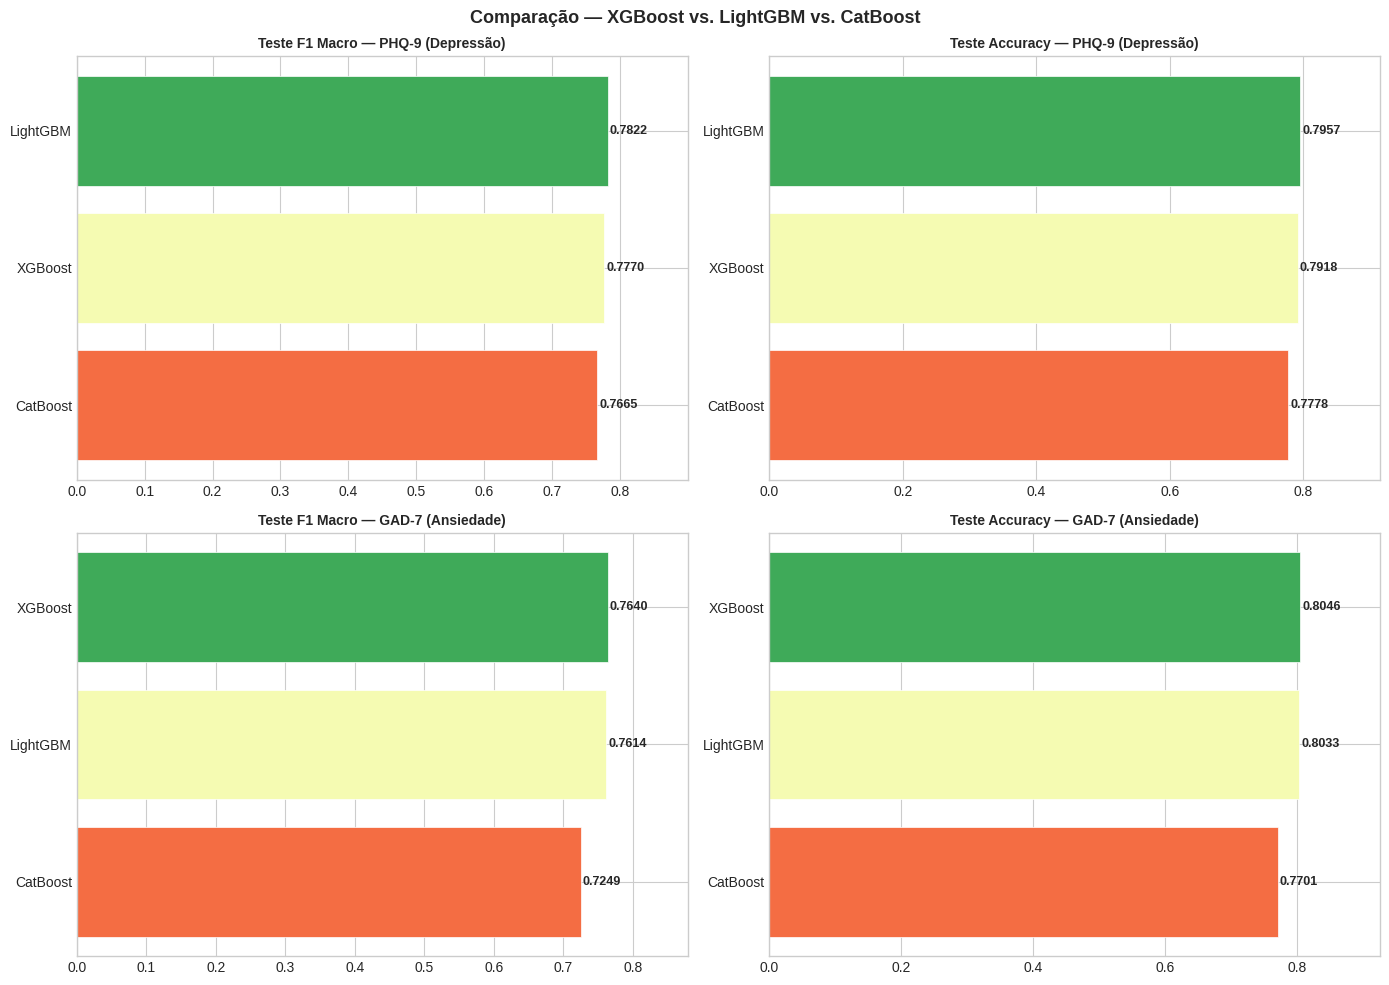

In [46]:
# Gráfico comparativo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (res_df, target_label) in enumerate([
    (results_phq9_df, 'PHQ-9 (Depressão)'),
    (results_gad7_df, 'GAD-7 (Ansiedade)')
]):
    for col, metric in enumerate(['Teste F1 Macro', 'Teste Accuracy']):
        vals = res_df[metric].sort_values(ascending=True)
        colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(vals)))
        axes[row, col].barh(vals.index, vals.values,
                             color=colors_bar, edgecolor='white', linewidth=0.5)
        axes[row, col].set_title(f'{metric} — {target_label}', fontweight='bold', fontsize=10)
        axes[row, col].set_xlim(0, vals.max() * 1.15)
        for i, (idx, val) in enumerate(vals.items()):
            axes[row, col].text(val + 0.003, i, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparação — XGBoost vs. LightGBM vs. CatBoost',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

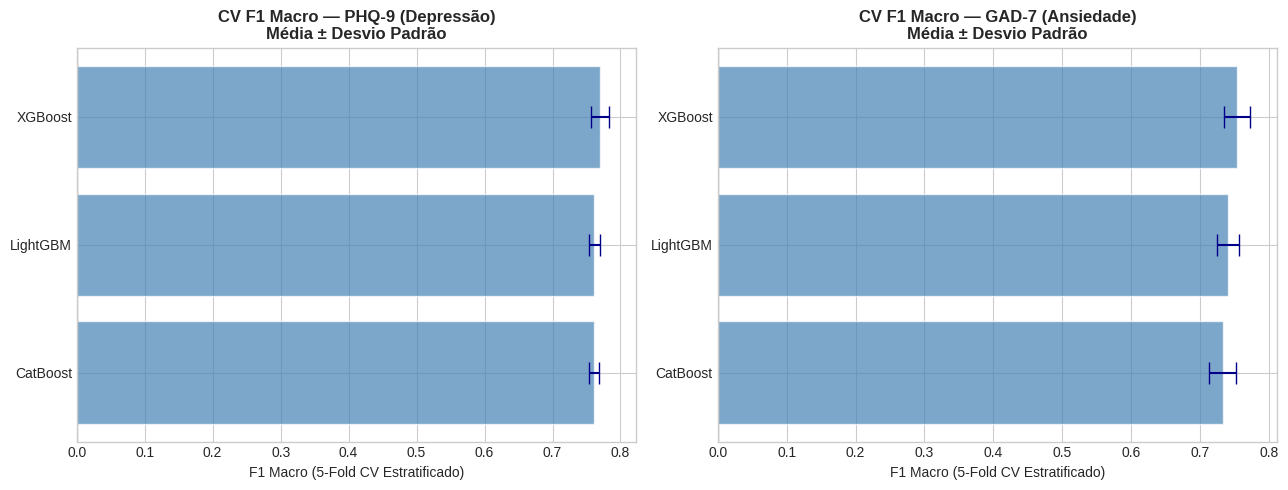

In [47]:
# CV F1 Macro com intervalo de confiança
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res_df, title in zip(axes,
    [results_phq9_df, results_gad7_df],
    ['PHQ-9 (Depressão)', 'GAD-7 (Ansiedade)']):

    cv_data = res_df[['CV F1 Macro (média)', 'CV F1 Macro (std)']]\
        .sort_values('CV F1 Macro (média)', ascending=True)
    y_pos = range(len(cv_data))
    ax.barh(y_pos, cv_data['CV F1 Macro (média)'],
            xerr=cv_data['CV F1 Macro (std)'],
            color='steelblue', alpha=0.7, ecolor='darkblue',
            capsize=8, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cv_data.index, fontsize=10)
    ax.set_xlabel('F1 Macro (5-Fold CV Estratificado)')
    ax.set_title(f'CV F1 Macro — {title}\nMédia ± Desvio Padrão', fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## 7. Análise Detalhada — Melhor Modelo por Target

In [48]:
best_phq9 = results_phq9_df['Teste F1 Macro'].idxmax()
best_gad7 = results_gad7_df['Teste F1 Macro'].idxmax()

print(f'🏆 Melhor modelo PHQ-9: {best_phq9}')
print(f'   Teste F1 Macro:  {results_phq9_df.loc[best_phq9, "Teste F1 Macro"]:.4f}')
print(f'   Teste Accuracy:  {results_phq9_df.loc[best_phq9, "Teste Accuracy"]:.4f}')
print()
print(f'🏆 Melhor modelo GAD-7: {best_gad7}')
print(f'   Teste F1 Macro:  {results_gad7_df.loc[best_gad7, "Teste F1 Macro"]:.4f}')
print(f'   Teste Accuracy:  {results_gad7_df.loc[best_gad7, "Teste Accuracy"]:.4f}')

🏆 Melhor modelo PHQ-9: LightGBM
   Teste F1 Macro:  0.7822
   Teste Accuracy:  0.7957

🏆 Melhor modelo GAD-7: XGBoost
   Teste F1 Macro:  0.7640
   Teste Accuracy:  0.8046


In [49]:
# Classification Reports
print(f'=== Classification Report — {best_phq9} (PHQ-9) ===')
print(classification_report(y_test_phq9_str, predictions_phq9[best_phq9], zero_division=0))

print(f'=== Classification Report — {best_gad7} (GAD-7) ===')
print(classification_report(y_test_gad7_str, predictions_gad7[best_gad7], zero_division=0))

=== Classification Report — LightGBM (PHQ-9) ===
              precision    recall  f1-score   support

       Grave       0.87      0.91      0.89        53
        Leve       0.71      0.76      0.73       208
  Mod. grave       0.84      0.67      0.74        81
    Moderada       0.67      0.67      0.67       111
      Mínima       0.87      0.88      0.87       330

    accuracy                           0.80       783
   macro avg       0.79      0.77      0.78       783
weighted avg       0.80      0.80      0.80       783

=== Classification Report — XGBoost (GAD-7) ===
              precision    recall  f1-score   support

       Grave       0.88      0.81      0.84        57
        Leve       0.64      0.62      0.63       180
    Moderada       0.69      0.68      0.69       109
      Mínima       0.89      0.91      0.90       437

    accuracy                           0.80       783
   macro avg       0.78      0.75      0.76       783
weighted avg       0.80      0.80 

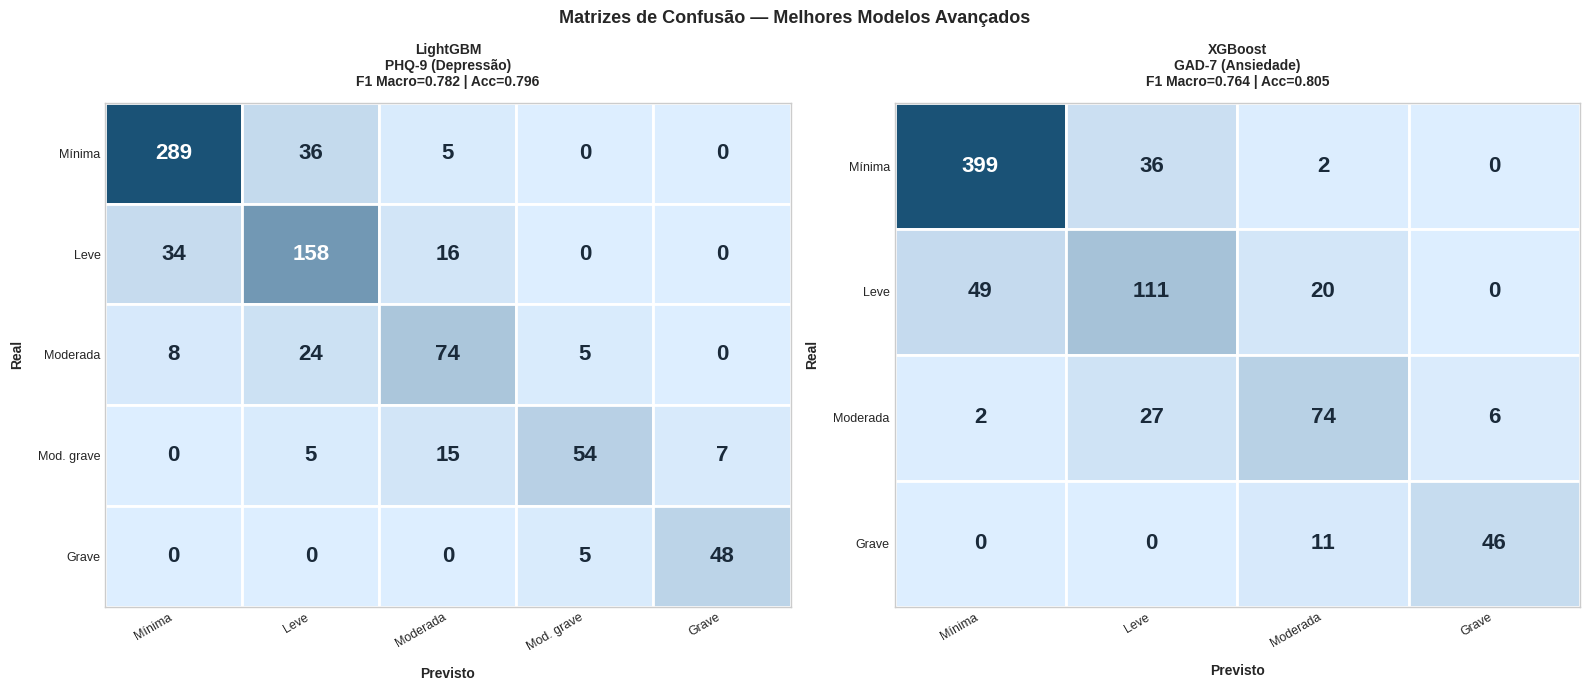

In [50]:
# Matrizes de confusão — melhor modelo de cada target
labels_phq9_ord = ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']
labels_gad7_ord = ['Mínima', 'Leve', 'Moderada', 'Grave']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Matrizes de Confusão — Melhores Modelos Avançados',
             fontweight='bold', fontsize=13)

for ax, y_test, y_pred, title, labels in [
    (axes[0], y_test_phq9_str, predictions_phq9[best_phq9],
     f'{best_phq9}\nPHQ-9 (Depressão)', labels_phq9_ord),
    (axes[1], y_test_gad7_str, predictions_gad7[best_gad7],
     f'{best_gad7}\nGAD-7 (Ansiedade)', labels_gad7_ord),
]:
    present = [l for l in labels if l in np.unique(list(y_test) + list(y_pred))]
    n = len(present)
    cm = confusion_matrix(y_test, y_pred, labels=present)
    cm_max = cm.max()

    for i in range(n):
        for j in range(n):
            val = cm[i, j]
            intensity = val / cm_max if cm_max > 0 else 0
            r = int(0xDD + (0x1A - 0xDD) * intensity)
            g = int(0xEE + (0x52 - 0xEE) * intensity)
            b = int(0xFF + (0x76 - 0xFF) * intensity)
            ax.add_patch(plt.Rectangle((j, n-1-i), 1, 1,
                                        facecolor=f'#{r:02X}{g:02X}{b:02X}',
                                        edgecolor='white', linewidth=2))
            text_color = 'white' if intensity > 0.5 else '#1A2A3A'
            ax.text(j + 0.5, n-1-i+0.5, str(val),
                    ha='center', va='center',
                    fontsize=16, fontweight='bold', color=text_color)

    ax.set_xlim(0, n); ax.set_ylim(0, n)
    ax.set_xticks([x+0.5 for x in range(n)])
    ax.set_yticks([y+0.5 for y in range(n)])
    ax.set_xticklabels(present, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(present[::-1], fontsize=9)
    ax.set_xlabel('Previsto', fontsize=10, fontweight='bold', labelpad=10)
    ax.set_ylabel('Real', fontsize=10, fontweight='bold', labelpad=10)
    ax.tick_params(length=0)
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{title}\nF1 Macro={f1:.3f} | Acc={acc:.3f}',
                 fontweight='bold', fontsize=10, pad=12)

plt.tight_layout()
plt.show()

In [51]:
# Matrizes normalizadas por linha
for y_test, y_pred, name, labels, target in [
    (y_test_phq9_str, predictions_phq9[best_phq9], best_phq9, labels_phq9_ord, 'PHQ-9'),
    (y_test_gad7_str, predictions_gad7[best_gad7], best_gad7, labels_gad7_ord, 'GAD-7'),
]:
    present = [l for l in labels if l in np.unique(list(y_test) + list(y_pred))]
    cm = confusion_matrix(y_test, y_pred, labels=present)
    cm_df = pd.DataFrame(cm, index=present, columns=present)
    cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)

    print(f'\n=== {target} — {name} ===')
    print('Proporção de cada classe real classificada em cada classe prevista:')
    display(cm_norm.round(3).style
        .background_gradient(cmap='RdYlGn', axis=None)
        .format('{:.1%}'))


=== PHQ-9 — LightGBM ===
Proporção de cada classe real classificada em cada classe prevista:


,Mínima,Leve,Moderada,Mod. grave,Grave
Mínima,87.6%,10.9%,1.5%,0.0%,0.0%
Leve,16.3%,76.0%,7.7%,0.0%,0.0%
Moderada,7.2%,21.6%,66.7%,4.5%,0.0%
Mod. grave,0.0%,6.2%,18.5%,66.7%,8.6%
Grave,0.0%,0.0%,0.0%,9.4%,90.6%



=== GAD-7 — XGBoost ===
Proporção de cada classe real classificada em cada classe prevista:


,Mínima,Leve,Moderada,Grave
Mínima,91.3%,8.2%,0.5%,0.0%
Leve,27.2%,61.7%,11.1%,0.0%
Moderada,1.8%,24.8%,67.9%,5.5%
Grave,0.0%,0.0%,19.3%,80.7%


---
## 8. GridSearchCV — Afinação de Hiperparâmetros

Aplicamos GridSearchCV a todos os modelos de cada target para verificar se a afinação de hiperparâmetros traz melhorias adicionais.

In [60]:
# GridSearchCV — todos os modelos avançados, PHQ-9 e GAD-7
# Grids de hiperparâmetros por modelo
param_grids_adv = {
    'XGBoost': {
        'n_estimators':  [200, 300, 500],
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample':     [0.7, 0.8, 1.0],
    },
    'LightGBM': {
        'n_estimators':  [200, 300, 500],
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample':     [0.7, 0.8, 1.0],
    },
    'CatBoost': {
        'iterations':    [200, 300, 500],
        'depth':         [4, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg':   [1, 3, 5],
    },
}

base_models_adv = {
    'XGBoost':  XGBClassifier(random_state=SEED, verbosity=0, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=SEED, verbosity=-1),
    'CatBoost': CatBoostClassifier(random_seed=SEED, verbose=0),
}

results_gs_phq9 = []
results_gs_gad7 = []
preds_gs_phq9   = {}
preds_gs_gad7   = {}
trained_gs_phq9 = {}
trained_gs_gad7 = {}

for model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
    for target, X_tr, X_te, y_tr, y_te_str, le, res_list, preds_dict in [
        ('PHQ-9', X_train_phq9_imp, X_test_phq9_imp,
         y_train_phq9, y_test_phq9_str, le_phq9,
         results_gs_phq9, preds_gs_phq9),
        ('GAD-7', X_train_gad7_imp, X_test_gad7_imp,
         y_train_gad7, y_test_gad7_str, le_gad7,
         results_gs_gad7, preds_gs_gad7),
    ]:
        gs = GridSearchCV(
            base_models_adv[model_name],
            param_grids_adv[model_name],
            cv=CV, scoring='f1_macro', n_jobs=-1
        )
        gs.fit(X_tr, y_tr)
        if target == 'PHQ-9':
          trained_gs_phq9[model_name] = gs.best_estimator_
        else:
          trained_gs_gad7[model_name] = gs.best_estimator_
        y_pred = le.inverse_transform(gs.predict(X_te).astype(int))

        f1  = f1_score(y_te_str, y_pred, average='macro', zero_division=0)
        acc = accuracy_score(y_te_str, y_pred)

        print(f'{model_name} ({target}) — params: {gs.best_params_} | CV F1: {gs.best_score_:.4f} | Teste F1: {f1:.4f} | Acc: {acc:.4f}')

        res_list.append({
            'Modelo': model_name,
            'CV F1 Macro (melhor)': gs.best_score_,
            'Teste F1 Macro': f1,
            'Teste Accuracy': acc,
            'Melhores Hiperparâmetros': str(gs.best_params_),
        })
        preds_dict[model_name] = y_pred

# Tabelas ordenadas por F1 Macro
gs_phq9_df = pd.DataFrame(results_gs_phq9).set_index('Modelo').sort_values('Teste F1 Macro', ascending=False)
gs_gad7_df = pd.DataFrame(results_gs_gad7).set_index('Modelo').sort_values('Teste F1 Macro', ascending=False)

print('\nPHQ-9 — Resultados GridSearchCV (modelos avançados):')
display(gs_phq9_df[['CV F1 Macro (melhor)', 'Teste F1 Macro', 'Teste Accuracy']].round(4).style
    .background_gradient(subset=['Teste F1 Macro'], cmap='RdYlGn')
    .background_gradient(subset=['Teste Accuracy'], cmap='RdYlGn')
    .format('{:.4f}')
    .set_caption('GridSearchCV — PHQ-9 (ordenado por Teste F1 Macro)'))

print('\nGAD-7 — Resultados GridSearchCV (modelos avançados):')
display(gs_gad7_df[['CV F1 Macro (melhor)', 'Teste F1 Macro', 'Teste Accuracy']].round(4).style
    .background_gradient(subset=['Teste F1 Macro'], cmap='RdYlGn')
    .background_gradient(subset=['Teste Accuracy'], cmap='RdYlGn')
    .format('{:.4f}')
    .set_caption('GridSearchCV — GAD-7 (ordenado por Teste F1 Macro)'))

# Melhores modelos finais
best_phq9_gs = gs_phq9_df['Teste F1 Macro'].idxmax()
best_gad7_gs = gs_gad7_df['Teste F1 Macro'].idxmax()

print(f'\n🏆 Melhor modelo PHQ-9 + GridSearchCV: {best_phq9_gs} | F1={gs_phq9_df.loc[best_phq9_gs, "Teste F1 Macro"]:.4f} | Acc={gs_phq9_df.loc[best_phq9_gs, "Teste Accuracy"]:.4f}')
print(f'🏆 Melhor modelo GAD-7 + GridSearchCV: {best_gad7_gs} | F1={gs_gad7_df.loc[best_gad7_gs, "Teste F1 Macro"]:.4f} | Acc={gs_gad7_df.loc[best_gad7_gs, "Teste Accuracy"]:.4f}')

XGBoost (PHQ-9) — params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8} | CV F1: 0.7784 | Teste F1: 0.7957 | Acc: 0.8148
XGBoost (GAD-7) — params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8} | CV F1: 0.7634 | Teste F1: 0.7758 | Acc: 0.8161
LightGBM (PHQ-9) — params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7} | CV F1: 0.7723 | Teste F1: 0.7919 | Acc: 0.8059
LightGBM (GAD-7) — params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7} | CV F1: 0.7613 | Teste F1: 0.7762 | Acc: 0.8097
CatBoost (PHQ-9) — params: {'depth': 7, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1} | CV F1: 0.7883 | Teste F1: 0.7925 | Acc: 0.8072
CatBoost (GAD-7) — params: {'depth': 7, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.1} | CV F1: 0.7658 | Teste F1: 0.7613 | Acc: 0.8059

PHQ-9 — Resultados GridSearchCV (modelos avançados):


,CV F1 Macro (melhor),Teste F1 Macro,Teste Accuracy
Modelo,,,
XGBoost,0.7784,0.7957,0.8148
CatBoost,0.7883,0.7925,0.8072
LightGBM,0.7723,0.7919,0.8059



GAD-7 — Resultados GridSearchCV (modelos avançados):


,CV F1 Macro (melhor),Teste F1 Macro,Teste Accuracy
Modelo,,,
LightGBM,0.7613,0.7762,0.8097
XGBoost,0.7634,0.7758,0.8161
CatBoost,0.7658,0.7613,0.8059



🏆 Melhor modelo PHQ-9 + GridSearchCV: XGBoost | F1=0.7957 | Acc=0.8148
🏆 Melhor modelo GAD-7 + GridSearchCV: LightGBM | F1=0.7762 | Acc=0.8097


In [61]:
print(f'\n🏆 Melhor modelo PHQ-9 + GridSearchCV: {best_phq9_gs} | F1={gs_phq9_df.loc[best_phq9_gs, "Teste F1 Macro"]:.4f} | Acc={gs_phq9_df.loc[best_phq9_gs, "Teste Accuracy"]:.4f}')

# GAD-7 — XGBoost adoptado pelo menor gap CV/teste (diferença de F1 negligenciável face ao LightGBM)
best_gad7_gs = 'XGBoost'
print(f'🏆 Melhor modelo GAD-7 + GridSearchCV: {best_gad7_gs} | F1={gs_gad7_df.loc[best_gad7_gs, "Teste F1 Macro"]:.4f} | Acc={gs_gad7_df.loc[best_gad7_gs, "Teste Accuracy"]:.4f}')


🏆 Melhor modelo PHQ-9 + GridSearchCV: XGBoost | F1=0.7957 | Acc=0.8148
🏆 Melhor modelo GAD-7 + GridSearchCV: XGBoost | F1=0.7758 | Acc=0.8161


In [62]:
import pickle

with open('/content/drive/MyDrive/IACD/Projeto/notebooks/modelos_avancados.pkl', 'wb') as f:
    pickle.dump({
        # Features e encoders
        'FEATURES': FEATURES,
        'le_phq9':  le_phq9,
        'le_gad7':  le_gad7,

        # Melhores modelos treinados (XGBoost + GridSearchCV para ambos)
        'melhor_modelo_phq9': trained_gs_phq9['XGBoost'],
        'melhor_modelo_gad7': trained_gs_gad7['XGBoost'],
        'melhor_nome_phq9':   'XGBoost',
        'melhor_nome_gad7':   'XGBoost',

        # Resultados
        'results_phq9_df': results_phq9_df,
        'results_gad7_df': results_gad7_df,
        'gs_phq9_df':      gs_phq9_df,
        'gs_gad7_df':      gs_gad7_df,

        # Previsões dos melhores
        'y_pred_phq9_best': preds_gs_phq9['XGBoost'],
        'y_pred_gad7_best': preds_gs_gad7['XGBoost'],
    }, f)

print('✅ Melhores modelos guardados com sucesso.')
print(f'   PHQ-9: XGBoost + GridSearchCV | F1=0.7957 | Acc=0.8148')
print(f'   GAD-7: XGBoost + GridSearchCV | F1=0.7758 | Acc=0.8161')

✅ Melhores modelos guardados com sucesso.
   PHQ-9: XGBoost + GridSearchCV | F1=0.7957 | Acc=0.8148
   GAD-7: XGBoost + GridSearchCV | F1=0.7758 | Acc=0.8161


---
## 9. Análise Detalhada — Melhor Modelo por Target

In [65]:
# Melhores Modelos + GridSearchCV
print(f'🏆 Melhor modelo PHQ-9: {best_phq9_gs} + GridSearchCV')
print(f'   Teste F1 Macro:  {gs_phq9_df.loc[best_phq9_gs, "Teste F1 Macro"]:.4f}')
print(f'   Teste Accuracy:  {gs_phq9_df.loc[best_phq9_gs, "Teste Accuracy"]:.4f}')
print()
print(f'🏆 Melhor modelo GAD-7: XGBoost + GridSearchCV')
print(f'   Teste F1 Macro:  {gs_gad7_df.loc["XGBoost", "Teste F1 Macro"]:.4f}')
print(f'   Teste Accuracy:  {gs_gad7_df.loc["XGBoost", "Teste Accuracy"]:.4f}')
print()

🏆 Melhor modelo PHQ-9: XGBoost + GridSearchCV
   Teste F1 Macro:  0.7957
   Teste Accuracy:  0.8148

🏆 Melhor modelo GAD-7: XGBoost + GridSearchCV
   Teste F1 Macro:  0.7758
   Teste Accuracy:  0.8161



In [66]:
# Classification Reports
print(f'=== Classification Report — {best_phq9_gs} + GridSearchCV (PHQ-9) ===')
print(classification_report(y_test_phq9_str, preds_gs_phq9[best_phq9_gs], zero_division=0))

print(f'=== Classification Report — XGBoost + GridSearchCV (GAD-7) ===')
print(classification_report(y_test_gad7_str, preds_gs_gad7['XGBoost'], zero_division=0))

=== Classification Report — XGBoost + GridSearchCV (PHQ-9) ===
              precision    recall  f1-score   support

       Grave       0.90      0.89      0.90        53
        Leve       0.73      0.81      0.77       208
  Mod. grave       0.83      0.67      0.74        81
    Moderada       0.68      0.68      0.68       111
      Mínima       0.90      0.89      0.89       330

    accuracy                           0.81       783
   macro avg       0.81      0.79      0.80       783
weighted avg       0.82      0.81      0.81       783

=== Classification Report — XGBoost + GridSearchCV (GAD-7) ===
              precision    recall  f1-score   support

       Grave       0.88      0.77      0.82        57
        Leve       0.66      0.66      0.66       180
    Moderada       0.71      0.72      0.72       109
      Mínima       0.90      0.91      0.90       437

    accuracy                           0.82       783
   macro avg       0.79      0.77      0.78       783
weigh

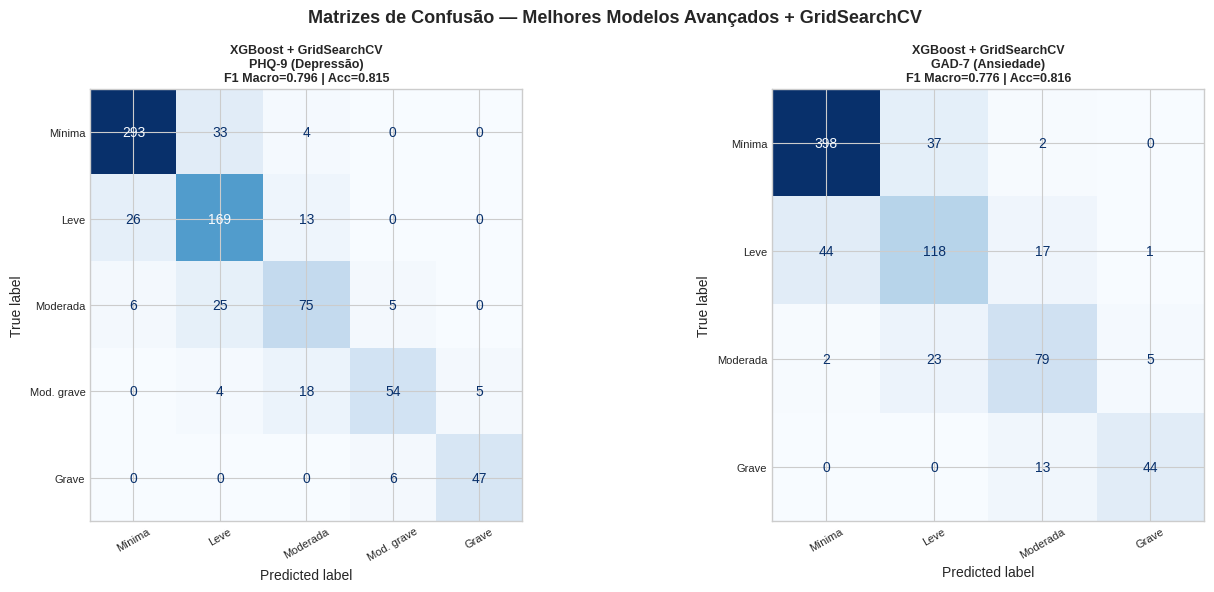

In [75]:
# Matrizes de confusão — Melhores Modelos Avançados + GridSearchCV
labels_phq9_ord = ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']
labels_gad7_ord = ['Mínima', 'Leve', 'Moderada', 'Grave']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Matrizes de Confusão — Melhores Modelos Avançados + GridSearchCV',
             fontweight='bold', fontsize=13)

for ax, y_test, y_pred, title, labels in [
    (axes[0], y_test_phq9_str, preds_gs_phq9[best_phq9_gs],
     f'{best_phq9_gs} + GridSearchCV\nPHQ-9 (Depressão)', labels_phq9_ord),
    (axes[1], y_test_gad7_str, preds_gs_gad7['XGBoost'],
     f'XGBoost + GridSearchCV\nGAD-7 (Ansiedade)', labels_gad7_ord),
]:
    present = [l for l in labels if l in np.unique(list(y_test) + list(y_pred))]
    cm = confusion_matrix(y_test, y_pred, labels=present)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{title}\nF1 Macro={f1:.3f} | Acc={acc:.3f}',
                 fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [68]:
# Matrizes normalizadas por linha
for y_test, y_pred, name, labels, target in [
    (y_test_phq9_str, preds_gs_phq9[best_phq9_gs],
     f'{best_phq9_gs} + GridSearchCV', labels_phq9_ord, 'PHQ-9'),
    (y_test_gad7_str, preds_gs_gad7['XGBoost'],
     'XGBoost + GridSearchCV', labels_gad7_ord, 'GAD-7'),
]:
    present = [l for l in labels if l in np.unique(list(y_test) + list(y_pred))]
    cm = confusion_matrix(y_test, y_pred, labels=present)
    cm_df = pd.DataFrame(cm, index=present, columns=present)
    cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)

    print(f'\n=== {target} — {name} ===')
    print('Proporção de cada classe real classificada em cada classe prevista:')
    display(cm_norm.round(3).style
        .background_gradient(cmap='RdYlGn', axis=None)
        .format('{:.1%}'))


=== PHQ-9 — XGBoost + GridSearchCV ===
Proporção de cada classe real classificada em cada classe prevista:


,Mínima,Leve,Moderada,Mod. grave,Grave
Mínima,88.8%,10.0%,1.2%,0.0%,0.0%
Leve,12.5%,81.2%,6.2%,0.0%,0.0%
Moderada,5.4%,22.5%,67.6%,4.5%,0.0%
Mod. grave,0.0%,4.9%,22.2%,66.7%,6.2%
Grave,0.0%,0.0%,0.0%,11.3%,88.7%



=== GAD-7 — XGBoost + GridSearchCV ===
Proporção de cada classe real classificada em cada classe prevista:


,Mínima,Leve,Moderada,Grave
Mínima,91.1%,8.5%,0.5%,0.0%
Leve,24.4%,65.6%,9.4%,0.6%
Moderada,1.8%,21.1%,72.5%,4.6%
Grave,0.0%,0.0%,22.8%,77.2%


In [69]:
# SHAP e PDP — melhores modelos avançados + GridSearchCV
from matplotlib.patches import Patch

ACTIVITY_FEATURES = [
    'physical_activity_days_per_week',
    'physical_activity_minutes_per_session',
    'physical_activity_total_minutes_week',
    'physical_activity_type',
    'physical_activity_intensity',
]

model_shap_phq9 = trained_gs_phq9[best_phq9_gs]
model_shap_gad7 = trained_gs_gad7['XGBoost']

# Os modelos avançados não precisam de pipeline — já foram treinados directamente
# sobre X_train_phq9_imp (já imputado)
X_test_phq9_df = pd.DataFrame(X_test_phq9_imp, columns=FEATURES)
X_test_gad7_df = pd.DataFrame(X_test_gad7_imp, columns=FEATURES)

print('✅ Modelos e dados preparados para SHAP e PDP.')

✅ Modelos e dados preparados para SHAP e PDP.


---
## 9. Importância das Features — Permutation Importance

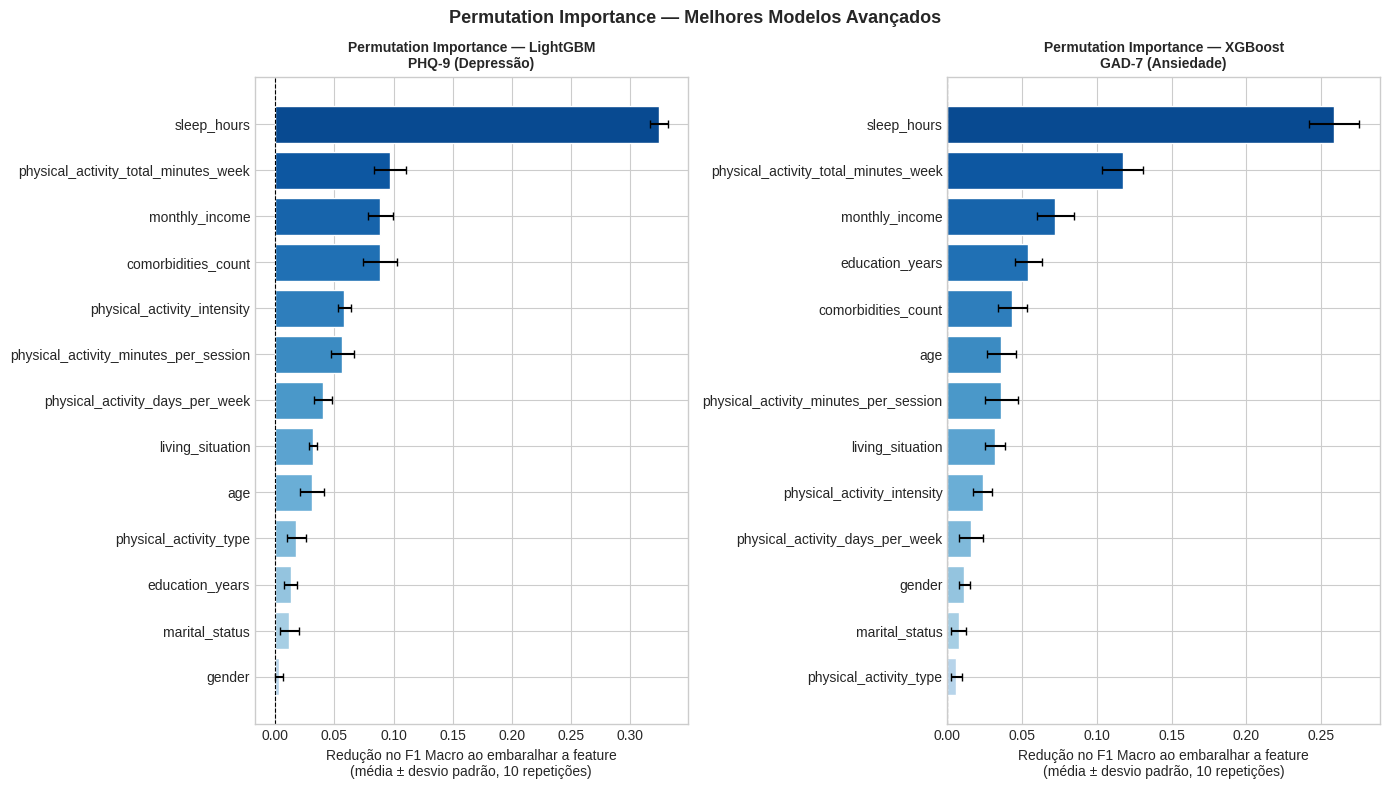

In [63]:
# Permutation Importance — melhores modelos de cada target
# Avaliada no conjunto de teste com os targets em string para F1 Macro legível

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, (X_train, X_test, y_train, y_test_str, model_name, le, target_label) in zip(axes, [
    (X_train_phq9_imp, X_test_phq9_imp, y_train_phq9,
     y_test_phq9_str, best_phq9, le_phq9, 'PHQ-9 (Depressão)'),
    (X_train_gad7_imp, X_test_gad7_imp, y_train_gad7,
     y_test_gad7_str, best_gad7, le_gad7, 'GAD-7 (Ansiedade)'),
]):
    model = models[model_name]
    model.fit(X_train, y_train)

    # Wrapper para usar F1 Macro com targets em string
    def score_fn(estimator, X, y_enc):
        y_pred = le.inverse_transform(estimator.predict(X).astype(int))
        y_true = le.inverse_transform(y_enc.astype(int))
        return f1_score(y_true, y_pred, average='macro', zero_division=0)

    result = permutation_importance(
        model, X_test, y_test_phq9 if target_label.startswith('PHQ') else y_test_gad7,
        n_repeats=10, random_state=SEED, n_jobs=-1,
        scoring=score_fn
    )

    feat_imp = pd.Series(result.importances_mean, index=FEATURES).sort_values(ascending=True)
    feat_err = pd.Series(result.importances_std, index=FEATURES).reindex(feat_imp.index)

    colors_imp = plt.cm.Blues(np.linspace(0.3, 0.9, len(feat_imp)))
    ax.barh(feat_imp.index, feat_imp.values,
            xerr=feat_err.values, color=colors_imp,
            edgecolor='white', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Permutation Importance — {model_name}\n{target_label}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Redução no F1 Macro ao embaralhar a feature\n(média ± desvio padrão, 10 repetições)')

plt.suptitle('Permutation Importance — Melhores Modelos Avançados',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

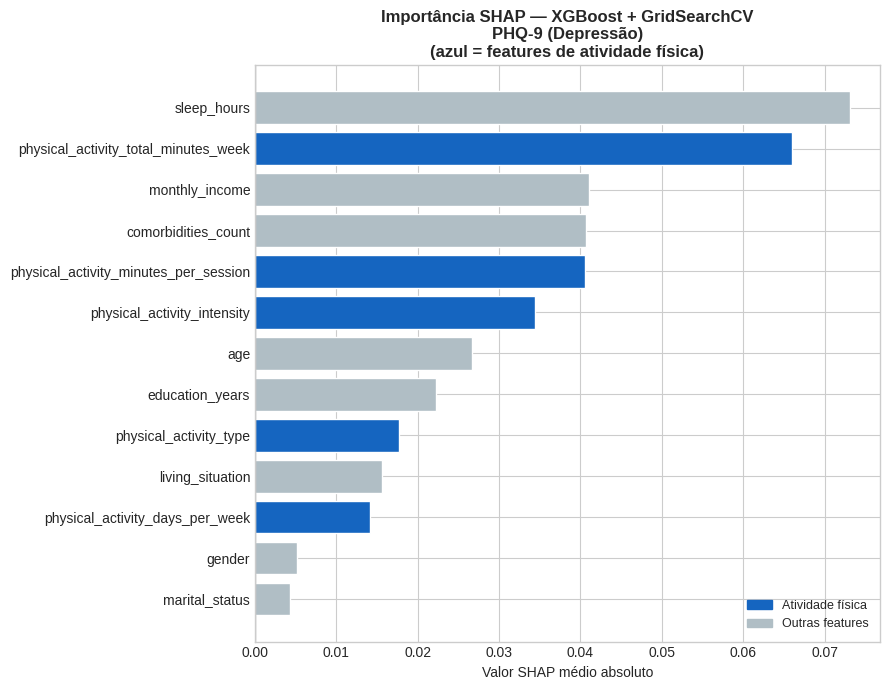

In [71]:
# SHAP — PHQ-9
import shap

background_phq9 = shap.sample(X_test_phq9_df, 50)
explainer_phq9  = shap.KernelExplainer(model_shap_phq9.predict_proba, background_phq9)
shap_values_phq9 = explainer_phq9.shap_values(X_test_phq9_df.sample(100, random_state=SEED))

if isinstance(shap_values_phq9, list):
    shap_mean_phq9 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_phq9], axis=0)
elif shap_values_phq9.ndim == 3:
    shap_mean_phq9 = np.abs(shap_values_phq9).mean(axis=(0, 2))
else:
    shap_mean_phq9 = np.abs(shap_values_phq9).mean(axis=0)

shap_df_phq9 = pd.DataFrame({
    'Feature': FEATURES,
    'SHAP': shap_mean_phq9
}).sort_values('SHAP', ascending=True)

colors_shap = ['#1565C0' if f in ACTIVITY_FEATURES else '#B0BEC5'
               for f in shap_df_phq9['Feature']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df_phq9['Feature'], shap_df_phq9['SHAP'],
        color=colors_shap, edgecolor='white')
ax.set_xlabel('Valor SHAP médio absoluto')
ax.set_title(f'Importância SHAP — {best_phq9_gs} + GridSearchCV\nPHQ-9 (Depressão)\n(azul = features de atividade física)',
             fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.legend(handles=[
    Patch(color='#1565C0', label='Atividade física'),
    Patch(color='#B0BEC5', label='Outras features')
], fontsize=9)
plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

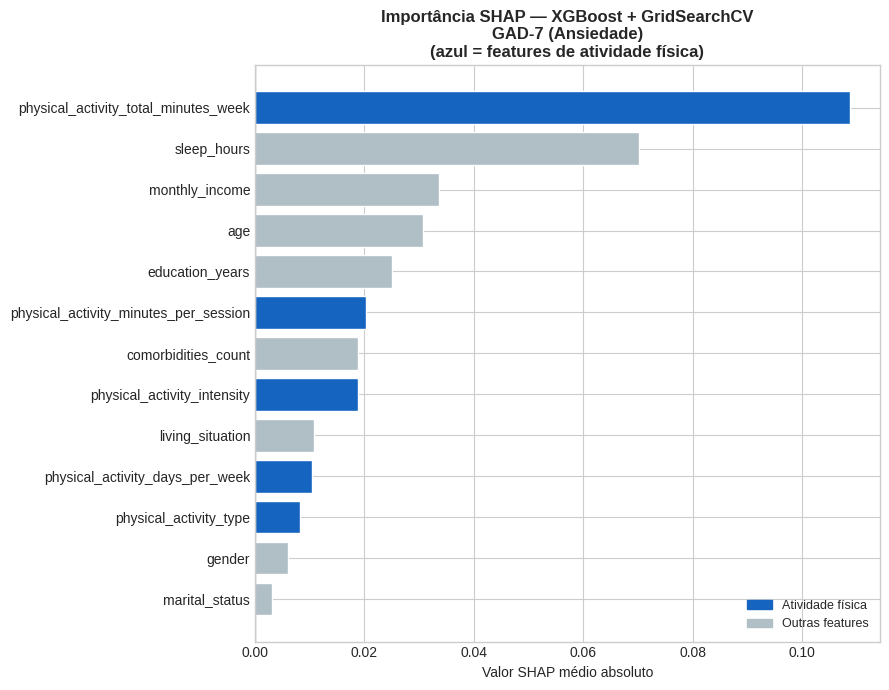

In [72]:
# SHAP — GAD-7
background_gad7  = shap.sample(X_test_gad7_df, 50)
explainer_gad7   = shap.KernelExplainer(model_shap_gad7.predict_proba, background_gad7)
shap_values_gad7 = explainer_gad7.shap_values(X_test_gad7_df.sample(100, random_state=SEED))

if isinstance(shap_values_gad7, list):
    shap_mean_gad7 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_gad7], axis=0)
elif shap_values_gad7.ndim == 3:
    shap_mean_gad7 = np.abs(shap_values_gad7).mean(axis=(0, 2))
else:
    shap_mean_gad7 = np.abs(shap_values_gad7).mean(axis=0)

shap_df_gad7 = pd.DataFrame({
    'Feature': FEATURES,
    'SHAP': shap_mean_gad7
}).sort_values('SHAP', ascending=True)

colors_shap_g = ['#1565C0' if f in ACTIVITY_FEATURES else '#B0BEC5'
                 for f in shap_df_gad7['Feature']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df_gad7['Feature'], shap_df_gad7['SHAP'],
        color=colors_shap_g, edgecolor='white')
ax.set_xlabel('Valor SHAP médio absoluto')
ax.set_title(f'Importância SHAP — XGBoost + GridSearchCV\nGAD-7 (Ansiedade)\n(azul = features de atividade física)',
             fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.legend(handles=[
    Patch(color='#1565C0', label='Atividade física'),
    Patch(color='#B0BEC5', label='Outras features')
], fontsize=9)
plt.tight_layout()
plt.show()

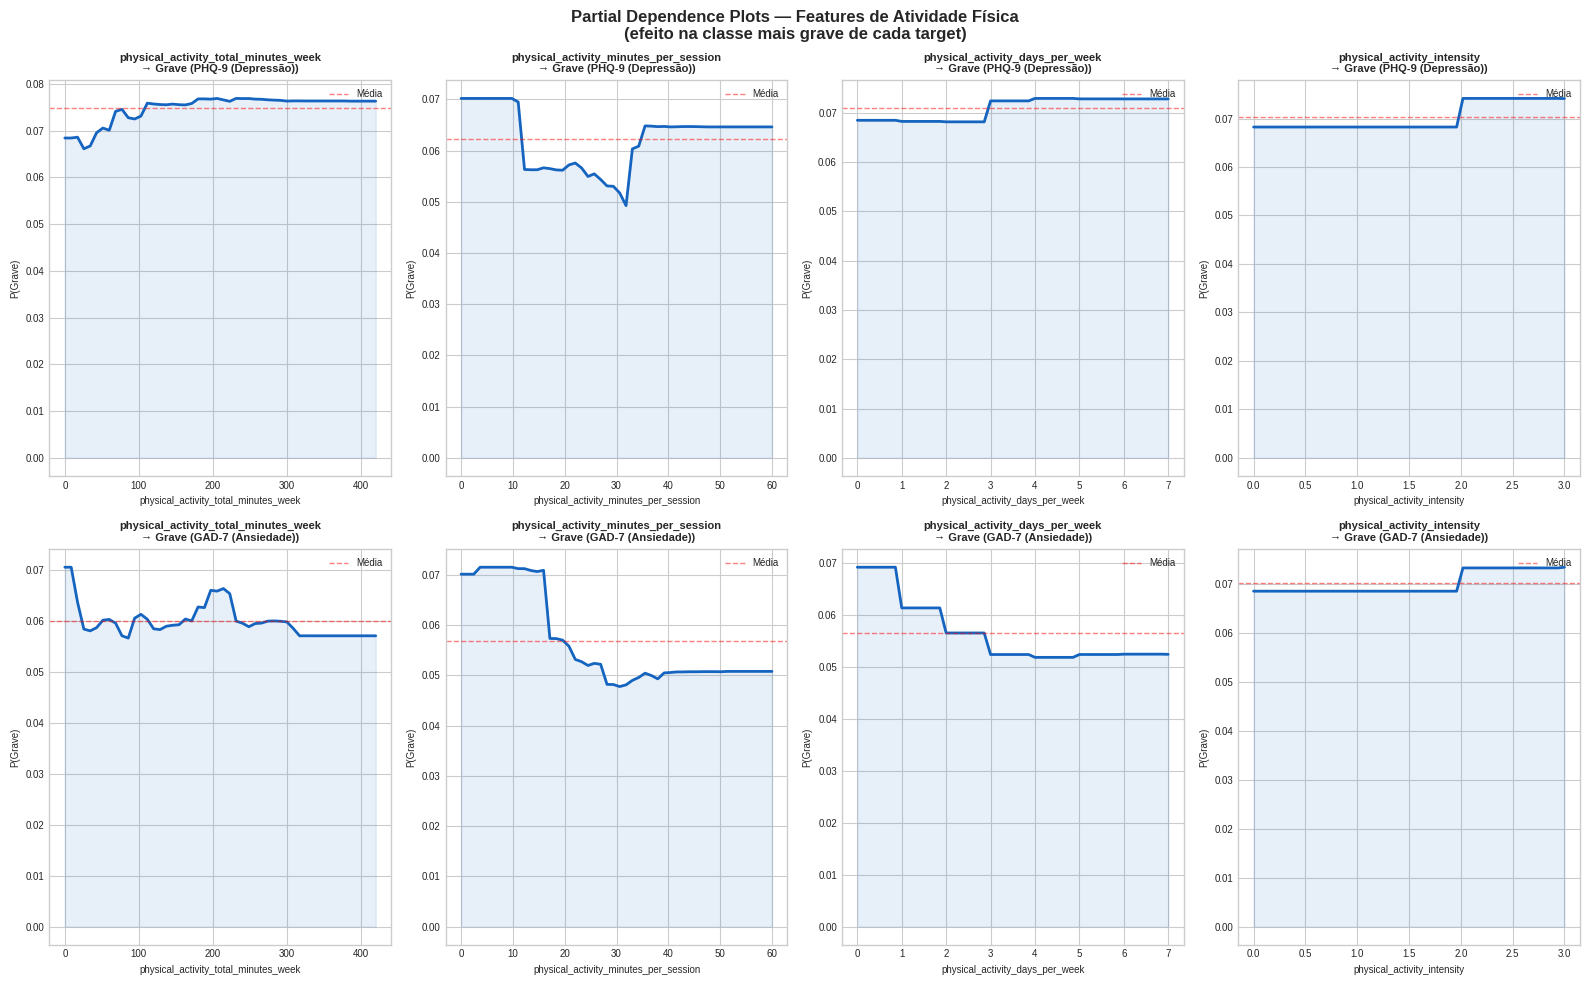

In [73]:
# PDP — features de atividade física
pdp_features = [
    'physical_activity_total_minutes_week',
    'physical_activity_minutes_per_session',
    'physical_activity_days_per_week',
    'physical_activity_intensity',
]
pdp_idx = [FEATURES.index(f) for f in pdp_features if f in FEATURES]

fig, axes = plt.subplots(2, len(pdp_idx), figsize=(16, 10))

for row, (model, X_test_df, X_test_orig, target_label, labels) in enumerate([
    (model_shap_phq9, X_test_phq9_df, X_test_phq9,
     'PHQ-9 (Depressão)', ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']),
    (model_shap_gad7, X_test_gad7_df, X_test_gad7,
     'GAD-7 (Ansiedade)', ['Mínima', 'Leve', 'Moderada', 'Grave']),
]):
    target_class = labels[-1]
    target_idx   = list(le_phq9.classes_ if row == 0 else le_gad7.classes_).index(target_class)

    for col, (feat, idx) in enumerate(zip(pdp_features, pdp_idx)):
        ax = axes[row, col]

        feat_values = np.linspace(
            X_test_df.iloc[:, idx].min(),
            X_test_df.iloc[:, idx].max(), 50
        )

        pdp_values = []
        X_copy = X_test_df.copy().values
        for val in feat_values:
            X_temp = X_copy.copy()
            X_temp[:, idx] = val
            proba = model.predict_proba(X_temp)[:, target_idx].mean()
            pdp_values.append(proba)

        feat_original    = X_test_orig[feat] if hasattr(X_test_orig, '__getitem__') else pd.DataFrame(X_test_orig, columns=FEATURES)[feat]
        feat_values_orig = np.linspace(feat_original.min(), feat_original.max(), 50)

        ax.plot(feat_values_orig, pdp_values, color='#1565C0', linewidth=2)
        ax.fill_between(feat_values_orig, pdp_values, alpha=0.1, color='#1565C0')
        ax.axhline(np.mean(pdp_values), color='red', linewidth=1,
                   linestyle='--', alpha=0.5, label='Média')
        ax.set_title(f'{feat}\n→ {target_class} ({target_label})',
                     fontweight='bold', fontsize=8)
        ax.set_xlabel(feat, fontsize=7)
        ax.set_ylabel(f'P({target_class})', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Partial Dependence Plots — Features de Atividade Física\n'
             '(efeito na classe mais grave de cada target)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

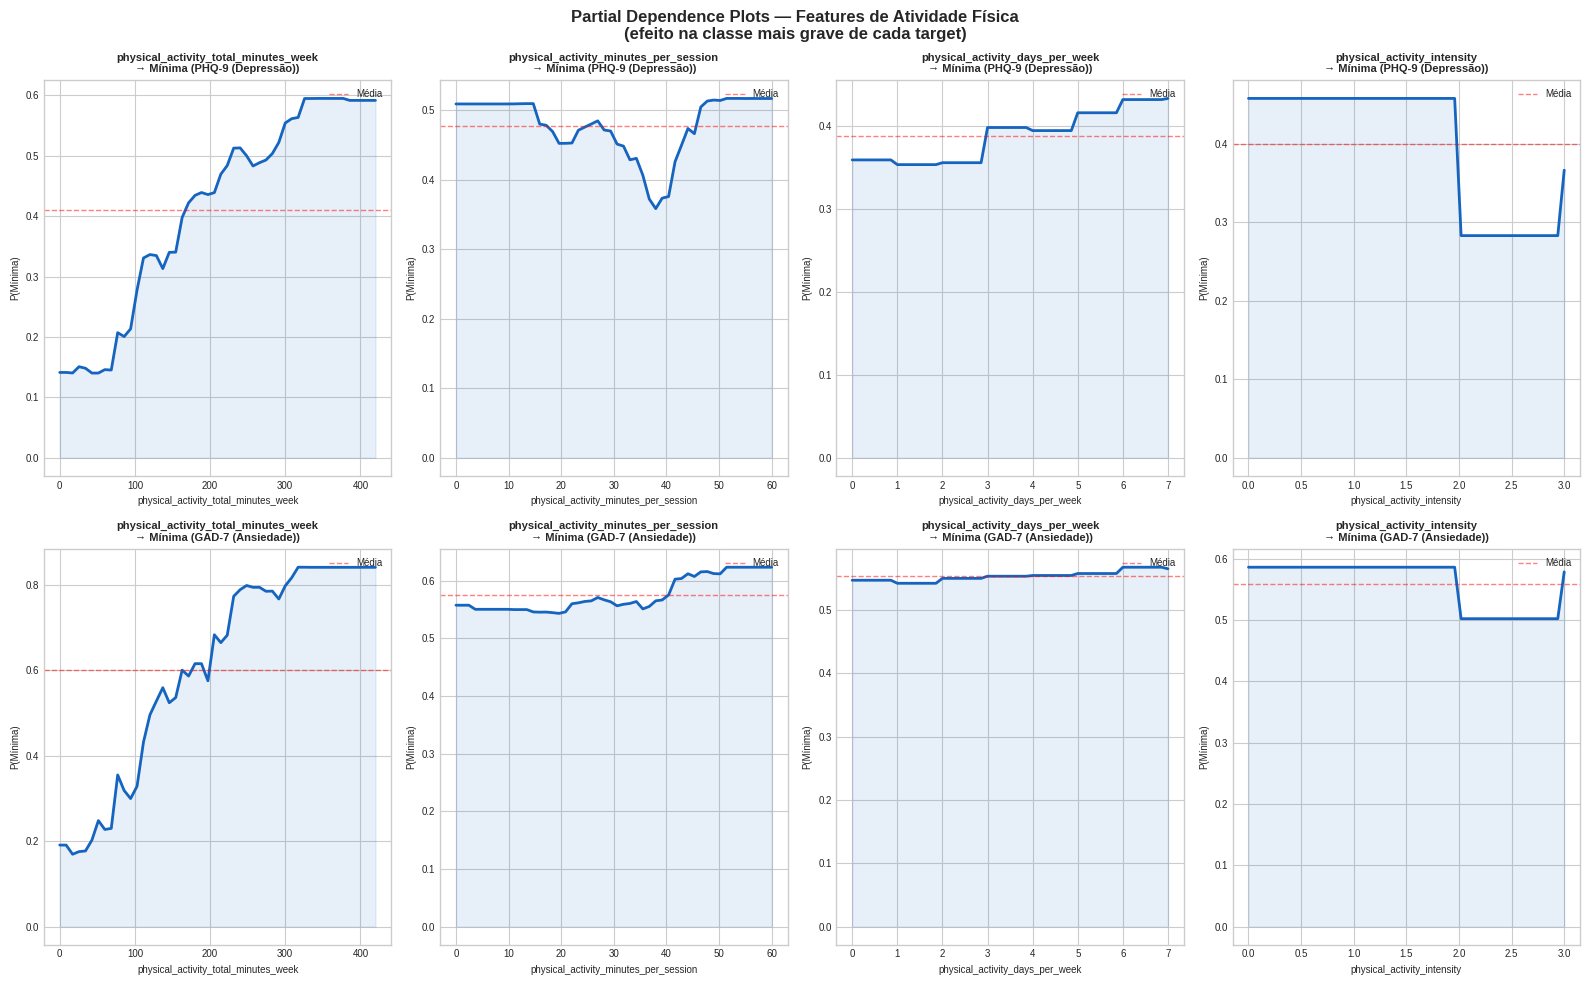

In [74]:
fig, axes = plt.subplots(2, len(pdp_idx), figsize=(16, 10))

for row, (model, X_test_df, X_test_orig, target_label, labels) in enumerate([
    (model_shap_phq9, X_test_phq9_df, X_test_phq9,
     'PHQ-9 (Depressão)', ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']),
    (model_shap_gad7, X_test_gad7_df, X_test_gad7,
     'GAD-7 (Ansiedade)', ['Mínima', 'Leve', 'Moderada', 'Grave']),
]):
    target_class = labels[0]
    target_idx   = list(le_phq9.classes_ if row == 0 else le_gad7.classes_).index(target_class)

    for col, (feat, idx) in enumerate(zip(pdp_features, pdp_idx)):
        ax = axes[row, col]

        feat_values = np.linspace(
            X_test_df.iloc[:, idx].min(),
            X_test_df.iloc[:, idx].max(), 50
        )

        pdp_values = []
        X_copy = X_test_df.copy().values
        for val in feat_values:
            X_temp = X_copy.copy()
            X_temp[:, idx] = val
            proba = model.predict_proba(X_temp)[:, target_idx].mean()
            pdp_values.append(proba)

        feat_original    = X_test_orig[feat] if hasattr(X_test_orig, '__getitem__') else pd.DataFrame(X_test_orig, columns=FEATURES)[feat]
        feat_values_orig = np.linspace(feat_original.min(), feat_original.max(), 50)

        ax.plot(feat_values_orig, pdp_values, color='#1565C0', linewidth=2)
        ax.fill_between(feat_values_orig, pdp_values, alpha=0.1, color='#1565C0')
        ax.axhline(np.mean(pdp_values), color='red', linewidth=1,
                   linestyle='--', alpha=0.5, label='Média')
        ax.set_title(f'{feat}\n→ {target_class} ({target_label})',
                     fontweight='bold', fontsize=8)
        ax.set_xlabel(feat, fontsize=7)
        ax.set_ylabel(f'P({target_class})', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Partial Dependence Plots — Features de Atividade Física\n'
             '(efeito na classe mais grave de cada target)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 11. Conclusões e Discussão

### Questão de Investigação

Este notebook complementou a análise de modelos tradicionais com três modelos de gradient boosting avançado, XGBoost, LightGBM e CatBoost, aplicados à mesma questão de investigação: **"Conseguimos prever o nível de depressão e ansiedade em idosos a partir de variáveis de estilo de vida e sociodemográficas, nomeadamente dados de atividade física?"**

**Sim.** Os modelos desenvolvidos, tanto tradicionais como avançados, demonstram que é possível prever o nível de depressão e ansiedade em idosos com desempenho expressivo e consistente, utilizando exclusivamente variáveis de estilo de vida e sociodemográficas, sem recurso a qualquer dado clínico direto.

### Síntese dos Resultados

**PHQ-9 (Depressão):** O XGBoost com GridSearchCV obteve o melhor desempenho (F1 Macro = 0.7957, Accuracy = 0.8148), superando o melhor modelo tradicional (Gradient Boosting, F1 Macro = 0.7802) em +0.0155. Os hiperparâmetros ótimos foram `learning_rate=0.1`, `max_depth=7`, `n_estimators=300` e `subsample=0.8`, com um gap mínimo entre validação cruzada (F1=0.7784) e teste (F1=0.7957), confirmando boa generalização. Os três modelos avançados com GridSearchCV ficaram muito próximos entre si (F1 entre 0.7919 e 0.7957), sugerindo que o tecto de desempenho para este problema está próximo com as features disponíveis.

**GAD-7 (Ansiedade):** O XGBoost com GridSearchCV foi adoptado como melhor modelo (F1 Macro = 0.7758, Accuracy = 0.8161), superando o melhor modelo tradicional (Gradient Boosting, F1 Macro = 0.7621) em +0.0137. Os hiperparâmetros ótimos foram `learning_rate=0.05`, `max_depth=7`, `n_estimators=300` e `subsample=0.8`. A escolha recaiu sobre o XGBoost pela maior Accuracy e pelo menor gap entre validação cruzada (F1=0.7634) e teste (F1=0.7758) face ao LightGBM, que apresentava F1 Macro marginalmente superior (0.0004 de diferença) mas menor estabilidade.

### Impacto da Atividade Física

A análise SHAP e os Partial Dependence Plots revelam um papel central e consistente da atividade física na previsão de saúde mental em idosos, com padrões distintos entre os dois targets.

**SHAP — PHQ-9:** O `sleep_hours` é o preditor dominante, mas o `physical_activity_total_minutes_week` é o segundo preditor mais importante, seguido de `physical_activity_minutes_per_session` e `physical_activity_intensity`. No total, as features de atividade física ocupam quatro das seis posições mais relevantes, o que reforça a importância global da atividade física na previsão de depressão.

**SHAP — GAD-7:** O resultado é ainda mais expressivo, o `physical_activity_total_minutes_week` é o **preditor mais importante de todos**, superando inclusivamente o `sleep_hours`. Este resultado é particularmente relevante para a questão de investigação: para a ansiedade em idosos, o volume total de exercício semanal é o factor com maior poder explicativo de entre todas as variáveis disponíveis.

**PDP — Classe Grave:** Os PDP para a classe mais grave mostram que o XGBoost captura relações mais complexas e não lineares do que os modelos tradicionais. Para o GAD-7, a probabilidade de pertencer à classe Grave diminui claramente com o aumento dos minutos por sessão e dos dias por semana de exercício. Para o PHQ-9, a relação é mais estável, sugerindo que outros fatores dominam a distinção para os casos mais graves.

**PDP — Classe Mínima:** Os PDP para a classe Mínima são os mais expressivos e clinicamente relevantes. Para o GAD-7, a probabilidade de pertencer à classe Mínima (sem sintomas significativos de ansiedade) aumenta de ~18% para ~82% à medida que os minutos totais de exercício semanal aumentam, uma variação de 64 pontos percentuais. Para o PHQ-9, o efeito é igualmente pronunciado, com a probabilidade de depressão mínima a aumentar de ~14% para ~60% com o aumento do exercício semanal. Estes resultados constituem a evidência mais directa e clinicamente interpretável do efeito protetor da atividade física na saúde mental de idosos obtida neste estudo.

Embora o sono emerja como o preditor dominante no PHQ-9, a atividade física supera-o no GAD-7 e mantém-se consistentemente entre os dois preditores mais importantes em ambos os targets. Sono e exercício físico são fatores protetores complementares e independentes, amplamente reconhecidos na literatura clínica sobre saúde mental em idosos.

### Resposta à Questão de Investigação

O melhor modelo para a depressão (PHQ-9), XGBoost com GridSearchCV, atingiu F1 Macro = 0.7957 e Accuracy = 0.8148, classificando corretamente cerca de 81% dos casos e com desempenho equilibrado entre as cinco classes clínicas. Para a ansiedade (GAD-7), o mesmo modelo atingiu F1 Macro = 0.7758 e Accuracy = 0.8161.

A análise SHAP e os PDP confirmam que a atividade física, em particular o volume total de exercício semanal, é o preditor modificável mais relevante em ambos os targets. Para a ansiedade, é mesmo o preditor mais importante de todos. Os PDP para a classe Mínima mostram que idosos que praticam mais exercício têm uma probabilidade substancialmente maior de não apresentar sintomas significativos de depressão ou ansiedade, com variações de 46 a 64 pontos percentuais entre os extremos da distribuição de exercício.

A atividade física não é o único fator relevante, o sono é igualmente determinante, mas é o **principal fator modificável e diretamente intervencionável** identificado neste estudo, o que reforça a sua importância clínica e prática para programas de promoção da saúde mental em idosos.

### Comparação com Modelos Tradicionais

| | Melhor Tradicional | Melhor Avançado | Melhoria |
|---|---|---|---|
| PHQ-9 F1 Macro | 0.7802 (Gradient Boosting) | 0.7957 (XGBoost) | +0.0155 |
| GAD-7 F1 Macro | 0.7621 (Gradient Boosting) | 0.7758 (XGBoost) | +0.0137 |
| PHQ-9 Accuracy | 0.7944 | 0.8148 | +0.0204 |
| GAD-7 Accuracy | 0.8072 | 0.8161 | +0.0089 |

Os modelos avançados superaram consistentemente os tradicionais em ambos os targets e métricas. A melhoria mais expressiva verifica-se na Accuracy do PHQ-9 (+0.0204), sugerindo que o XGBoost capta melhor as fronteiras entre as cinco classes clínicas de depressão.

### Limitações

- **Natureza sintética dos dados:** Os padrões no dataset podem não refletir a complexidade e variabilidade de uma população real de idosos, limitando a validade externa dos resultados.
- **Features disponíveis:** O tecto de desempenho parece estar próximo com as features atuais, variáveis como historial clínico de saúde mental, suporte social ou eventos de vida recentes teriam provavelmente maior poder preditivo.
- **Interpretabilidade causal:** Os resultados mostram associações estatísticas, não relações causais. A natureza sintética do dataset impede conclusões clínicas directas.
- **Desequilíbrio de classes:** As classes minoritárias continuam a ser o principal desafio, o F1 Macro reportado é conservador relativamente ao desempenho nas classes maioritárias.